### Домашнее задание 3 - 10 баллов

Нужно обучить 2 модели по тексту отзыва и предсказать рейтинг (1–5):

1) Conv1d модель  
2) LSTM модель  
3) Улучшить одну модель  
4) Сравнить качество и графики обучения  

Будем делать мультиклассовую классификацию: 5 классов.


# Подготовка окружения
Фиксируем seed и подключаем нужные библиотеки.

In [1]:
!pip install pytorch_lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 59.7 MB/s eta 0:00:00


In [2]:
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger

import matplotlib.pyplot as plt


In [3]:
SEED = 42

pl.seed_everything(SEED, workers=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE


INFO:lightning_fabric.utilities.seed:Seed set to 42


'cuda'

# Скачивание датасета

Каггл-датасет требует аккаунт и токен. Для ноутбука удобнее скачать тот же CSV с Hugging Face.


In [4]:
DATA_URL = "https://huggingface.co/datasets/patrickbdevaney/tripadvisor_hotel_reviews/resolve/main/data/tripadvisor_hotel_reviews.csv"
DATA_FILE = Path("tripadvisor_hotel_reviews.csv")

if not DATA_FILE.exists():
    !wget -O tripadvisor_hotel_reviews.csv "$DATA_URL"

DATA_FILE.exists()


--2026-01-11 16:31:01--  https://huggingface.co/datasets/patrickbdevaney/tripadvisor_hotel_reviews/resolve/main/data/tripadvisor_hotel_reviews.csv
Resolving huggingface.co (huggingface.co)... 3.165.160.59, 3.165.160.61, 3.165.160.12, ...
Connecting to huggingface.co (huggingface.co)|3.165.160.59|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/66af0624ccc0fb38839c3ccc/61ca403903cd97641068e650b39c9a27d56c67506e8dbe08f1b0edafd3d9666b?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27tripadvisor_hotel_reviews.csv%3B+filename%3D%22tripadvisor_hotel_reviews.csv%22%3B&response-content-type=text%2Fcsv&Expires=1768152661&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiRXBvY2hUaW1lIjoxNzY4MTUyNjYxfX0sIlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjZhZjA2MjRjY2MwZmIzODgzOWMzY2NjLzYxY2E0MDM5MDNjZDk3NjQxMDY4ZTY1MGIzOWM5YTI3ZDU2YzY3NTA2ZThkYmUwOGYxYjBlZGFmZDNkOTY2NmJcXD9yZXNwb25

True

# Загрузка данных
Читаем CSV и смотрим колонки.

In [5]:
df = pd.read_csv(DATA_FILE)
df.head()


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


# Подготовка данных

Оставляем только:
- текст отзыва
- рейтинг (1–5)

Делаем простую чистку текста и токенизацию по пробелам.


In [7]:
def infer_columns(frame):
    text_col = None
    rating_col = None

    for c in frame.columns:
        if frame[c].dtype == "object":
            s = frame[c].dropna().astype(str)
            if len(s) and s.map(len).mean() >= 20:
                text_col = c
                break

    for c in frame.columns:
        if pd.api.types.is_numeric_dtype(frame[c]):
            uniq = frame[c].dropna().unique()
            if 2 <= len(uniq) <= 10:
                rating_col = c
                break

    return text_col, rating_col


TOKEN_RE = re.compile(r"[^a-z0-9\s]+")

def normalize_text(text):
    text = str(text).lower()
    text = TOKEN_RE.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return normalize_text(text).split()


text_col, rating_col = infer_columns(df)


In [8]:
df = df[[text_col, rating_col]].dropna().reset_index(drop=True)
df[rating_col] = df[rating_col].astype(int)

df["text_norm"] = df[text_col].map(normalize_text)
df["tokens"] = df["text_norm"].map(tokenize)

df[[text_col, rating_col, "text_norm"]].head()


,Review,Rating,text_norm
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4 experience hotel monaco seatt...
3,"unique, great stay, wonderful time hotel monac...",5,unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",5,great stay great stay went seahawk game awesom...


In [9]:
lengths = df["tokens"].map(len)
lengths.describe(percentiles=[0.5, 0.8, 0.9, 0.95, 0.99])


,tokens
count,20491.000000
mean,108.469426
std,105.033969
min,7.000000
50%,80.000000
80%,147.000000
90%,210.000000
95%,287.000000
99%,522.100000
max,2039.000000


# Сплиты 60/20/20
Делаем train/val/test со стратификацией по рейтингу.

In [10]:
y_raw = df[rating_col].to_numpy()

train_df, temp_df = train_test_split(
    df,
    test_size=0.4,
    random_state=SEED,
    stratify=y_raw,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_df[rating_col].to_numpy(),
)

len(train_df), len(val_df), len(test_df)

(12294, 4098, 4099)

In [11]:
def show_dist(name, frame):
    dist = frame[rating_col].value_counts(normalize=True).sort_index()
    print(name, "n=", len(frame))
    print(dist.to_string())
    print()

show_dist("train", train_df)
show_dist("val", val_df)
show_dist("test", test_df)


train n= 12294
Rating
1    0.069383
2    0.087522
3    0.106556
4    0.294697
5    0.441842

val n= 4098
Rating
1    0.069302
2    0.087360
3    0.106637
4    0.294778
5    0.441923

test n= 4099
Rating
1    0.069285
2    0.087582
3    0.106611
4    0.294706
5    0.441815



# Словарь и длина последовательности

Словарь строим только по train.

Ограничиваем длину max_len, чтобы обучение было быстрым и не падало по памяти.


In [12]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

def build_vocab(token_lists, min_freq, max_vocab):
    freqs = {}
    for toks in token_lists:
        for t in toks:
            freqs[t] = freqs.get(t, 0) + 1

    items = sorted(freqs.items(), key=lambda x: (-x[1], x[0]))
    words = [w for w, c in items if c >= min_freq]
    itos = [PAD_TOKEN, UNK_TOKEN] + words[: max(0, max_vocab - 2)]
    stoi = {w: i for i, w in enumerate(itos)}
    return stoi, itos, stoi[PAD_TOKEN], stoi[UNK_TOKEN]

MIN_FREQ = 2
MAX_VOCAB = 30000
MAX_LEN = int(lengths.quantile(0.95))

stoi, itos, pad_id, unk_id = build_vocab(train_df["tokens"], MIN_FREQ, MAX_VOCAB)
len(itos), MAX_LEN


(20407, 287)

# Dataset и DataModule
Готовим батчи: паддинг до max_len, плюс реальные длины для LSTM.

In [13]:
class HotelReviewsDataset(Dataset):
    def __init__(self, frame, stoi, max_len, rating_col):
        self.tokens = frame["tokens"].tolist()
        y = frame[rating_col].astype(int).to_numpy()
        self.y = (y - y.min()).astype(np.int64)
        self.stoi = stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        toks = self.tokens[idx][: self.max_len]
        ids = [self.stoi.get(t, unk_id) for t in toks]
        return ids, int(self.y[idx])

def collate_batch(batch, pad_id, max_len):
    x_list, y_list = zip(*batch)
    lengths = torch.tensor([min(len(x), max_len) for x in x_list], dtype=torch.long)

    bsz = len(x_list)
    x = torch.full((bsz, max_len), fill_value=pad_id, dtype=torch.long)
    for i, ids in enumerate(x_list):
        ids = ids[:max_len]
        if len(ids):
            x[i, : len(ids)] = torch.tensor(ids, dtype=torch.long)

    y = torch.tensor(y_list, dtype=torch.long)
    return x, lengths, y

class ReviewsDataModule(pl.LightningDataModule):
    def __init__(self, train_df, val_df, test_df, stoi, max_len, batch_size, rating_col):
        super().__init__()
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        self.stoi = stoi
        self.max_len = max_len
        self.batch_size = batch_size
        self.rating_col = rating_col

    def setup(self, stage=None):
        if stage in (None, "fit"):
            self.train_ds = HotelReviewsDataset(self.train_df, self.stoi, self.max_len, self.rating_col)
            self.val_ds = HotelReviewsDataset(self.val_df, self.stoi, self.max_len, self.rating_col)
        if stage in (None, "test"):
            self.test_ds = HotelReviewsDataset(self.test_df, self.stoi, self.max_len, self.rating_col)

    def train_dataloader(self):
        return DataLoader(
            self.train_ds,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=2,
            pin_memory=torch.cuda.is_available(),
            collate_fn=lambda b: collate_batch(b, pad_id, self.max_len),
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_ds,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=torch.cuda.is_available(),
            collate_fn=lambda b: collate_batch(b, pad_id, self.max_len),
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_ds,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=torch.cuda.is_available(),
            collate_fn=lambda b: collate_batch(b, pad_id, self.max_len),
        )

BATCH_SIZE = 128

dm = ReviewsDataModule(train_df, val_df, test_df, stoi, MAX_LEN, BATCH_SIZE, rating_col)
dm.setup("fit")

batch = next(iter(dm.train_dataloader()))
batch[0].shape, batch[1][:5], batch[2][:5]


(torch.Size([128, 287]), tensor([48, 64, 83, 35, 58]), tensor([1, 3, 1, 4, 1]))

# Метрики

Считаем:
- accuracy
- macro F1

Macro F1 важен, потому что классы в датасете несбалансированы.


In [14]:
def confmat_update(confmat, preds, y, num_classes):
    k = y * num_classes + preds
    bins = torch.bincount(k, minlength=num_classes * num_classes)
    confmat += bins.reshape(num_classes, num_classes)

def confmat_metrics(confmat):
    tp = torch.diag(confmat).float()
    fp = confmat.sum(dim=0).float() - tp
    fn = confmat.sum(dim=1).float() - tp

    p = tp / (tp + fp).clamp(min=1)
    r = tp / (tp + fn).clamp(min=1)
    f1 = 2 * p * r / (p + r).clamp(min=1e-12)

    acc = tp.sum() / confmat.sum().float().clamp(min=1)
    f1_macro = f1.mean()
    return acc, f1_macro

# Общий LightningModule

Одинаковые настройки обучения для честного сравнения:
- CrossEntropy
- AdamW
- EarlyStopping по val_f1_macro


In [15]:
class TextClassifier(pl.LightningModule):
    def __init__(self, num_classes, lr, weight_decay):
        super().__init__()
        self.num_classes = num_classes
        self.lr = lr
        self.weight_decay = weight_decay

        self.val_confmat = torch.zeros(num_classes, num_classes, dtype=torch.long)
        self.test_confmat = torch.zeros(num_classes, num_classes, dtype=torch.long)

        self.val_loss_sum = 0.0
        self.val_count = 0

        self.test_loss_sum = 0.0
        self.test_count = 0

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=1)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sch, "monitor": "val_f1_macro"}}

    def training_step(self, batch, batch_idx):
        x, lengths, y = batch
        logits = self(x, lengths)
        loss = F.cross_entropy(logits, y)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=False)
        return loss

    def on_validation_epoch_start(self):
        self.val_confmat.zero_()
        self.val_loss_sum = 0.0
        self.val_count = 0

    def validation_step(self, batch, batch_idx):
        x, lengths, y = batch
        logits = self(x, lengths)
        loss = F.cross_entropy(logits, y)

        preds = torch.argmax(logits, dim=1)
        confmat_update(self.val_confmat, preds.cpu(), y.cpu(), self.num_classes)

        self.val_loss_sum += float(loss.detach().cpu()) * len(y)
        self.val_count += len(y)

    def on_validation_epoch_end(self):
        acc, f1_macro = confmat_metrics(self.val_confmat)
        val_loss = self.val_loss_sum / max(1, self.val_count)
        self.log("val_loss", val_loss, prog_bar=False)
        self.log("val_acc", acc, prog_bar=True)
        self.log("val_f1_macro", f1_macro, prog_bar=True)

    def on_test_epoch_start(self):
        self.test_confmat.zero_()
        self.test_loss_sum = 0.0
        self.test_count = 0

    def test_step(self, batch, batch_idx):
        x, lengths, y = batch
        logits = self(x, lengths)
        loss = F.cross_entropy(logits, y)

        preds = torch.argmax(logits, dim=1)
        confmat_update(self.test_confmat, preds.cpu(), y.cpu(), self.num_classes)

        self.test_loss_sum += float(loss.detach().cpu()) * len(y)
        self.test_count += len(y)

    def on_test_epoch_end(self):
        acc, f1_macro = confmat_metrics(self.test_confmat)
        test_loss = self.test_loss_sum / max(1, self.test_count)
        self.log("test_loss", test_loss)
        self.log("test_acc", acc)
        self.log("test_f1_macro", f1_macro)


# Модель 1: Conv1d

Схема:
Embedding - несколько Conv1d - global max pooling - классификатор


In [16]:
class Conv1DClassifier(TextClassifier):
    def __init__(self, vocab_size, pad_id, num_classes, emb_dim, channels, dropout, lr):
        super().__init__(num_classes=num_classes, lr=lr, weight_decay=1e-2)
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)

        self.conv3 = nn.Conv1d(emb_dim, channels, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(emb_dim, channels, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(emb_dim, channels, kernel_size=7, padding=3)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(channels * 3, num_classes)

    def forward(self, x, lengths):
        emb = self.embedding(x).transpose(1, 2)

        h3 = F.relu(self.conv3(emb))
        h5 = F.relu(self.conv5(emb))
        h7 = F.relu(self.conv7(emb))

        p3 = torch.amax(h3, dim=2)
        p5 = torch.amax(h5, dim=2)
        p7 = torch.amax(h7, dim=2)

        h = torch.cat([p3, p5, p7], dim=1)
        h = self.dropout(h)
        return self.fc(h)


In [17]:
num_classes = int(df[rating_col].nunique())

cnn = Conv1DClassifier(
    vocab_size=len(itos),
    pad_id=pad_id,
    num_classes=num_classes,
    emb_dim=128,
    channels=128,
    dropout=0.2,
    lr=2e-3,
)

logger_cnn = CSVLogger("lightning_logs", name="cnn")
ckpt_cnn = ModelCheckpoint(monitor="val_f1_macro", mode="max", save_top_k=1, filename="best")
early_cnn = EarlyStopping(monitor="val_f1_macro", mode="max", patience=2)

trainer_cnn = pl.Trainer(
    accelerator="auto",
    devices=1,
    max_epochs=8,
    logger=logger_cnn,
    callbacks=[ckpt_cnn, early_cnn],
    deterministic=True,
    log_every_n_steps=10,
)

trainer_cnn.fit(cnn, datamodule=dm)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ embedding │ Embedding │  2.6 M │ train │     0 │
│ 1 │ conv3     │ Conv1d    │ 49.3 K │ train │     0 │
│ 2 │ conv5     │ Conv1d    │ 82.0 K │ train │     0 │
│ 3 │ conv7     │ Conv1d    │  114 K │ train │     0 │
│ 4 │ dropout   │ Dropout   │      0 │ train │     0 │
│ 5 │ fc        │ Linear    │  1.9 K │ train │     0 │
└───┴───────────┴───────────┴────────┴───────┴───────┘

Trainable params: 2.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.9 M                                                                                                
Total estimated model params size (MB): 11                                                                         
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

In [21]:
test_cnn = trainer_cnn.test(cnn, datamodule=dm, verbose=False)[0]
test_cnn


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

{'test_loss': 1.1420872211456299,
 'test_acc': 0.5418394804000854,
 'test_f1_macro': 0.37272128462791443}

# Модель 2: LSTM

Схема:
Embedding - LSTM - берём последний hidden - классификатор


In [22]:
class LSTMClassifier(TextClassifier):
    def __init__(self, vocab_size, pad_id, num_classes, emb_dim, hidden_dim, dropout, lr):
        super().__init__(num_classes=num_classes, lr=lr, weight_decay=1e-2)
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        h = torch.cat([h_n[-2], h_n[-1]], dim=1)
        h = self.dropout(h)
        return self.fc(h)


In [23]:
lstm = LSTMClassifier(
    vocab_size=len(itos),
    pad_id=pad_id,
    num_classes=num_classes,
    emb_dim=128,
    hidden_dim=192,
    dropout=0.2,
    lr=2e-3,
)

logger_lstm = CSVLogger("lightning_logs", name="lstm")
ckpt_lstm = ModelCheckpoint(monitor="val_f1_macro", mode="max", save_top_k=1, filename="best")
early_lstm = EarlyStopping(monitor="val_f1_macro", mode="max", patience=2)

trainer_lstm = pl.Trainer(
    accelerator="auto",
    devices=1,
    max_epochs=8,
    logger=logger_lstm,
    callbacks=[ckpt_lstm, early_lstm],
    deterministic=True,
    log_every_n_steps=10,
)

trainer_lstm.fit(lstm, datamodule=dm)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ embedding │ Embedding │  2.6 M │ train │     0 │
│ 1 │ lstm      │ LSTM      │  494 K │ train │     0 │
│ 2 │ dropout   │ Dropout   │      0 │ train │     0 │
│ 3 │ fc        │ Linear    │  1.9 K │ train │     0 │
└───┴───────────┴───────────┴────────┴───────┴───────┘

Trainable params: 3.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.1 M                                                                                                
Total estimated model params size (MB): 12                                                                         
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

In [25]:
test_lstm = trainer_lstm.test(lstm, datamodule=dm, verbose=False)[0]
test_lstm


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

{'test_loss': 1.1759802103042603,
 'test_acc': 0.5611124634742737,
 'test_f1_macro': 0.5121229887008667}

# Улучшение модели

Улучшаем LSTM:
- больше размерность
- 2 слоя
- attention pooling по токенам


In [29]:
class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.proj = nn.Linear(dim, dim)
        self.v = nn.Linear(dim, 1, bias=False)

    def forward(self, x, mask):
        h = torch.tanh(self.proj(x))
        scores = self.v(h).squeeze(-1)
        scores = scores.masked_fill(~mask, float("-inf"))
        w = torch.softmax(scores, dim=1)
        return torch.sum(x * w.unsqueeze(-1), dim=1)


class LSTMAttnClassifier(TextClassifier):
    def __init__(self, vocab_size, pad_id, num_classes, emb_dim, hidden_dim, dropout, lr):
        super().__init__(num_classes=num_classes, lr=lr, weight_decay=1e-2)
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout,
        )
        out_dim = hidden_dim * 2
        self.pool = AttentionPool(out_dim)
        self.dropout = nn.Dropout(dropout)
        self.mlp = nn.Sequential(
            nn.Linear(out_dim, out_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim, num_classes),
        )

    def forward(self, x, lengths):
        emb = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out, batch_first=True, total_length=x.size(1)
        )

        bsz = x.size(0)
        seq_len = out.size(1)
        idx = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(bsz, seq_len)
        mask = idx < lengths.unsqueeze(1)

        pooled = self.pool(out, mask)
        pooled = self.dropout(pooled)
        return self.mlp(pooled)

In [30]:
lstm_attn = LSTMAttnClassifier(
    vocab_size=len(itos),
    pad_id=pad_id,
    num_classes=num_classes,
    emb_dim=192,
    hidden_dim=256,
    dropout=0.3,
    lr=2e-3,
)

logger_attn = CSVLogger("lightning_logs", name="lstm_attn")
ckpt_attn = ModelCheckpoint(monitor="val_f1_macro", mode="max", save_top_k=1, filename="best")
early_attn = EarlyStopping(monitor="val_f1_macro", mode="max", patience=2)

trainer_attn = pl.Trainer(
    accelerator="auto",
    devices=1,
    max_epochs=10,
    logger=logger_attn,
    callbacks=[ckpt_attn, early_attn],
    deterministic=True,
    log_every_n_steps=10,
)

trainer_attn.fit(lstm_attn, datamodule=dm)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ embedding │ Embedding     │  3.9 M │ train │     0 │
│ 1 │ lstm      │ LSTM          │  2.5 M │ train │     0 │
│ 2 │ pool      │ AttentionPool │  263 K │ train │     0 │
│ 3 │ dropout   │ Dropout       │      0 │ train │     0 │
│ 4 │ mlp       │ Sequential    │  265 K │ train │     0 │
└───┴───────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 6.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.9 M                                                                                                
Total estimated model params size (MB): 27                                                                         
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

In [31]:
test_attn = trainer_attn.test(lstm_attn, datamodule=dm, verbose=False)[0]
test_attn


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

{'test_loss': 1.1055266857147217,
 'test_acc': 0.615272045135498,
 'test_f1_macro': 0.5149182081222534}

# Сравнение моделей

Собираем test метрики и строим графики val_loss и val_f1_macro.


In [32]:
def read_metrics(logger):
    p = Path(logger.log_dir) / "metrics.csv"
    m = pd.read_csv(p)
    return m

m_cnn = read_metrics(logger_cnn)
m_lstm = read_metrics(logger_lstm)
m_attn = read_metrics(logger_attn)

summary = pd.DataFrame(
    [
        {"model": "Conv1d", "test_acc": test_cnn["test_acc"], "test_f1": test_cnn["test_f1_macro"]},
        {"model": "LSTM", "test_acc": test_lstm["test_acc"], "test_f1": test_lstm["test_f1_macro"]},
        {"model": "LSTM + Attn", "test_acc": test_attn["test_acc"], "test_f1": test_attn["test_f1_macro"]},
    ]
).sort_values("test_f1", ascending=False)

summary


,model,test_acc,test_f1
2,LSTM + Attn,0.615272,0.514918
1,LSTM,0.561112,0.512123
0,Conv1d,0.541839,0.372721


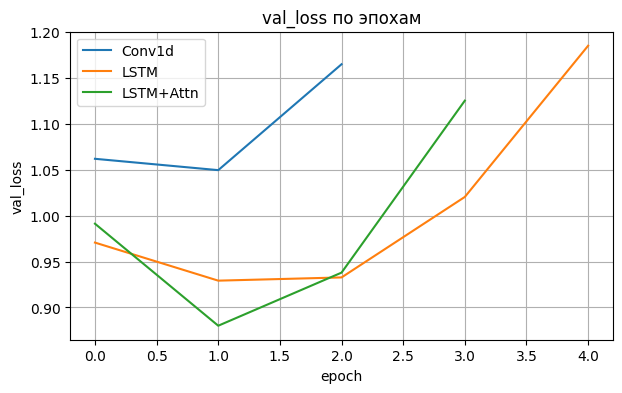

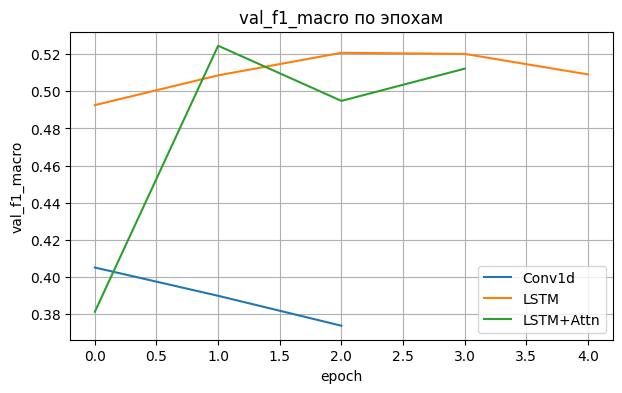

In [33]:
def plot_metric(metrics_list, col, title):
    plt.figure(figsize=(7, 4))
    for name, m in metrics_list:
        v = m.dropna(subset=[col]).sort_values("epoch")
        if len(v):
            plt.plot(v["epoch"], v[col], label=name)
    plt.xlabel("epoch")
    plt.ylabel(col)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_metric([("Conv1d", m_cnn), ("LSTM", m_lstm), ("LSTM+Attn", m_attn)], "val_loss", "val_loss по эпохам")
plot_metric([("Conv1d", m_cnn), ("LSTM", m_lstm), ("LSTM+Attn", m_attn)], "val_f1_macro", "val_f1_macro по эпохам")


* Модель 1 (Conv1d) - быстрый базовый текстовый классификатор по локальным шаблонам:

  * test_acc = 0.5418, test_f1_macro = 0.3727
    Вывод: как быстрый baseline годится, но macro-F1 провален - модель плохо покрывает редкие классы.
* Модель 2 (LSTM) - учитывает порядок и контекст:

  * test_acc = 0.5611, test_f1_macro = 0.5121
    Вывод: небольшой прирост accuracy, но огромный скачок macro-F1 - LSTM заметно лучше распределяет качество между классами.
* Улучшение (LSTM + attention pooling):

  * test_acc = 0.6153, test_f1_macro = 0.5149
    Вывод: attention резко поднимает accuracy, но macro-F1 почти не растёт - улучшения в основном приходятся на частые классы; редкие классы всё ещё ограничивают macro-F1.
* Практический вывод: для дисбалансной 5-классовой шкалы «лучшее по accuracy» и «лучшее по macro-F1» могут быть разными; если важны все рейтинги, стоит использовать macro-F1.
* Что реально может поднять macro-F1 дальше: веса классов/FocalLoss, другая токенезация, предобученные эмбеддинги.